<a href="https://colab.research.google.com/github/JV-ANUBIS/Sistemas-inteligentes/blob/main/Projeto5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ Projeto 5 — Detecção de Intrusão com MLP

---

## 📌 Introdução

A segurança de redes de computadores é um dos principais desafios da infraestrutura digital moderna. Ataques cibernéticos podem comprometer sistemas corporativos, serviços de comunicação, instituições financeiras e infraestruturas críticas.

Sistemas de Detecção de Intrusão (IDS — Intrusion Detection Systems) são utilizados para identificar atividades suspeitas e possíveis ataques em redes de computadores. Com o avanço do aprendizado de máquina, técnicas baseadas em redes neurais passaram a ser amplamente utilizadas para automatizar esse processo de detecção.

Neste projeto, será utilizada uma rede neural do tipo **MLP (Multilayer Perceptron)** implementada em PyTorch para classificar conexões de rede como normais ou ataques.

O conjunto de dados utilizado será o **NSL-KDD**, uma versão refinada do clássico KDD Cup 1999, contendo atributos relacionados ao tráfego de rede e diferentes tipos de ataques cibernéticos.

O problema será tratado como uma classificação binária:

- **0 → conexão normal**
- **1 → ataque**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report
)

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

## 📊 Conjunto de Dados

O dataset utilizado neste projeto é o **NSL-KDD**, uma versão aprimorada do KDD Cup 1999 voltada para pesquisas em detecção de intrusão.

Cada registro representa uma conexão de rede contendo 41 atributos relacionados ao tráfego, protocolos, conteúdo e comportamento das conexões.

Os dados estão divididos em dois arquivos:

- **KDDTrain+.txt** → utilizado para treinamento
- **KDDTest+.txt** → utilizado para teste

O problema será tratado como classificação binária:
- 0 → conexão normal
- 1 → ataque

In [2]:
col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "attack_type", "difficulty_level"
]

# Carregar treino e teste
train_df = pd.read_csv("KDDTrain+.txt", names=col_names)
test_df = pd.read_csv("KDDTest+.txt", names=col_names)

# Visualizar dados
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [3]:
# Remover coluna de dificuldade
train_df.drop("difficulty_level", axis=1, inplace=True)
test_df.drop("difficulty_level", axis=1, inplace=True)

# Converter rótulos:
# normal -> 0
# qualquer ataque -> 1

train_df["attack_type"] = train_df["attack_type"].apply(
    lambda x: 0 if x == "normal" else 1
)

test_df["attack_type"] = test_df["attack_type"].apply(
    lambda x: 0 if x == "normal" else 1
)

# Verificar distribuição
print(train_df["attack_type"].value_counts())

attack_type
0    67343
1    58630
Name: count, dtype: int64


In [4]:
categorical_cols = ["protocol_type", "service", "flag"]

# Aplicar One-Hot Encoding
train_df = pd.get_dummies(train_df, columns=categorical_cols)
test_df = pd.get_dummies(test_df, columns=categorical_cols)

# Alinhar colunas entre treino e teste
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

# Verificar dimensões
print("Treino:", train_df.shape)
print("Teste:", test_df.shape)


Treino: (125973, 123)
Teste: (22544, 123)


## 📏 Normalização dos Dados

Os atributos numéricos foram normalizados utilizando a técnica Z-score.

A normalização é importante para garantir estabilidade no treinamento da rede neural, evitando que atributos com escalas muito diferentes influenciem de forma desigual o processo de aprendizado.

As estatísticas utilizadas na normalização (média e desvio padrão) foram calculadas apenas sobre o conjunto de treino, evitando vazamento de informação para o conjunto de teste.

In [5]:
# Separar entradas e saídas
X_train_full = train_df.drop("attack_type", axis=1)
y_train_full = train_df["attack_type"]

X_test = test_df.drop("attack_type", axis=1)
y_test = test_df["attack_type"]

# Normalização Z-score
scaler = StandardScaler()

X_train_full = scaler.fit_transform(X_train_full)
X_test = scaler.transform(X_test)

In [6]:
# Tamanho da validação (20%)
val_size = int(0.2 * len(X_train_full))

# Separação sem embaralhamento
X_val = X_train_full[-val_size:]
y_val = y_train_full[-val_size:]

X_train = X_train_full[:-val_size]
y_train = y_train_full[:-val_size]

print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

Treino: (100779, 122)
Validação: (25194, 122)
Teste: (22544, 122)


In [7]:
# Converter para tensores
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [8]:
# Criar datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Criar dataloaders
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

## 🧠 Implementação da MLP

A rede neural utilizada neste projeto é do tipo MLP (*Multilayer Perceptron*), composta por camadas totalmente conectadas.

Foram utilizadas duas camadas ocultas com função de ativação ReLU, permitindo que o modelo aprenda relações não lineares entre os atributos do tráfego de rede.

A camada de saída possui apenas um neurônio e não utiliza função de ativação, pois a função de perda `BCEWithLogitsLoss` já aplica internamente a função sigmoide de forma numericamente estável.

In [9]:
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

In [10]:
# Criar modelo
model = MLP(input_size=122)

# Função de perda
criterion = nn.BCEWithLogitsLoss()

# Otimizador Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 🚀 Treinamento da Rede

A rede foi treinada por 50 épocas utilizando o otimizador Adam e a função de perda BCEWithLogitsLoss.

Durante o treinamento, foram registradas as perdas de treino e validação, permitindo acompanhar o comportamento da rede e verificar possíveis sinais de overfitting.

Além disso, foi utilizada uma estratégia simples de parada antecipada (*early stopping*), interrompendo o treinamento caso a perda de validação deixasse de melhorar.

In [11]:
train_losses = []
val_losses = []

best_val_loss = float('inf')
patience = 5
counter = 0

num_epochs = 50

for epoch in range(num_epochs):

    # ===== TREINO =====
    model.train()
    running_train_loss = 0.0

    for inputs, targets in train_loader:

        targets = targets.view(-1, 1)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, targets)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ===== VALIDAÇÃO =====
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for inputs, targets in val_loader:

            targets = targets.view(-1, 1)

            outputs = model(inputs)

            loss = criterion(outputs, targets)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Época [{epoch+1}/{num_epochs}] "
          f"Treino: {avg_train_loss:.4f} | "
          f"Validação: {avg_val_loss:.4f}")

    # ===== EARLY STOPPING =====
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping ativado!")
        break

Época [1/50] Treino: 0.1216 | Validação: 0.0449
Época [2/50] Treino: 0.0359 | Validação: 0.0276
Época [3/50] Treino: 0.0246 | Validação: 0.0212
Época [4/50] Treino: 0.0196 | Validação: 0.0202
Época [5/50] Treino: 0.0182 | Validação: 0.0175
Época [6/50] Treino: 0.0167 | Validação: 0.0188
Época [7/50] Treino: 0.0159 | Validação: 0.0166
Época [8/50] Treino: 0.0149 | Validação: 0.0171
Época [9/50] Treino: 0.0144 | Validação: 0.0153
Época [10/50] Treino: 0.0135 | Validação: 0.0165
Época [11/50] Treino: 0.0132 | Validação: 0.0161
Época [12/50] Treino: 0.0126 | Validação: 0.0157
Época [13/50] Treino: 0.0122 | Validação: 0.0151
Época [14/50] Treino: 0.0120 | Validação: 0.0155
Época [15/50] Treino: 0.0116 | Validação: 0.0139
Época [16/50] Treino: 0.0113 | Validação: 0.0144
Época [17/50] Treino: 0.0113 | Validação: 0.0146
Época [18/50] Treino: 0.0112 | Validação: 0.0137
Época [19/50] Treino: 0.0109 | Validação: 0.0140
Época [20/50] Treino: 0.0107 | Validação: 0.0141
Época [21/50] Treino: 0.0103 

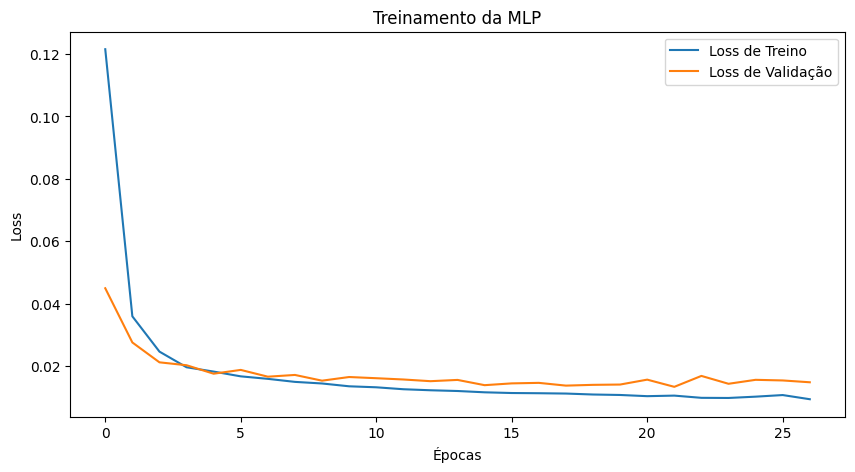

In [12]:
plt.figure(figsize=(10,5))

plt.plot(train_losses, label="Loss de Treino")
plt.plot(val_losses, label="Loss de Validação")

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Treinamento da MLP")

plt.legend()

plt.show()

## 📉 Análise do Treinamento

As curvas de loss de treino e validação apresentaram comportamento estável ao longo das épocas.

Observa-se uma redução significativa da função de perda nas primeiras épocas, indicando que a rede conseguiu aprender rapidamente os padrões presentes nos dados.

Além disso, as curvas permaneceram relativamente próximas durante o treinamento, sugerindo boa capacidade de generalização e baixo nível de overfitting.

A utilização da estratégia de parada antecipada (*early stopping*) permitiu interromper o treinamento automaticamente quando a perda de validação deixou de apresentar melhorias relevantes, evitando treinamento desnecessário e reduzindo o risco de sobreajuste.

In [14]:
model.eval()

with torch.no_grad():

    outputs = model(X_test_tensor)

    # Aplicar sigmoid
    probabilities = torch.sigmoid(outputs)

    # Threshold 0.5
    predictions = (probabilities >= 0.5).float()

# Converter para numpy
y_pred = predictions.numpy()
y_true = y_test_tensor.numpy()

In [15]:
print("Acurácia:", accuracy_score(y_true, y_pred))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_true, y_pred))

print("\nRelatório de Classificação:")
print(classification_report(y_true, y_pred))

Acurácia: 0.7958215046132009

Matriz de Confusão:
[[9004  707]
 [3896 8937]]

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.70      0.93      0.80      9711
         1.0       0.93      0.70      0.80     12833

    accuracy                           0.80     22544
   macro avg       0.81      0.81      0.80     22544
weighted avg       0.83      0.80      0.80     22544



## 📊 Avaliação do Modelo

O modelo MLP apresentou acurácia aproximada de **79,58%** no conjunto de teste, demonstrando capacidade satisfatória na detecção de ataques em conexões de rede.

A matriz de confusão obtida foi:

- Verdadeiros Negativos (TN): 9004  
- Falsos Positivos (FP): 707  
- Falsos Negativos (FN): 3896  
- Verdadeiros Positivos (TP): 8937  

Observa-se que o modelo apresentou alta precisão para a classe de ataques, indicando que a maioria das conexões classificadas como ataques realmente correspondia a atividades maliciosas.

Além disso, o modelo obteve recall elevado para conexões normais, demonstrando boa capacidade em identificar tráfego legítimo.

Os valores de F1-score próximos para ambas as classes indicam equilíbrio entre precisão e recall, evidenciando desempenho consistente do modelo.

## ⚠️ Análise de Erros em Sistemas IDS

Em sistemas reais de detecção de intrusão (IDS), o erro mais crítico é o **falso negativo**.

Esse erro ocorre quando uma conexão maliciosa é classificada como normal, permitindo que o ataque passe despercebido pelo sistema de segurança.

As consequências desse tipo de erro podem ser graves, incluindo:
- invasões não detectadas;
- vazamento de dados;
- comprometimento de serviços;
- interrupção de sistemas críticos.

Por outro lado, falsos positivos, apesar de inconvenientes, geralmente representam apenas alarmes incorretos que podem ser posteriormente analisados por administradores de rede.

A escolha do limiar de decisão afeta diretamente esse equilíbrio. Reduzir o limiar aumenta a sensibilidade do modelo, diminuindo falsos negativos, porém aumentando falsos positivos. Já aumentar o limiar reduz falsos positivos, mas pode permitir que ataques reais deixem de ser detectados.

## 🏁 Conclusão

Neste projeto, foi desenvolvida uma rede neural do tipo MLP utilizando PyTorch para classificação de conexões de rede em tráfego normal ou ataque, utilizando o dataset NSL-KDD.

As etapas de pré-processamento, incluindo codificação de atributos categóricos e normalização dos dados, foram fundamentais para garantir estabilidade e eficiência durante o treinamento da rede.

A arquitetura escolhida apresentou desempenho satisfatório, alcançando aproximadamente 79,58% de acurácia no conjunto de teste. As curvas de treinamento e validação demonstraram comportamento estável, indicando boa capacidade de generalização e baixo nível de overfitting.

Além disso, a utilização de BCEWithLogitsLoss, otimização com Adam e early stopping contribuiu para um treinamento mais robusto e eficiente.

Embora os resultados tenham sido positivos, o modelo ainda apresentou quantidade considerável de falsos negativos, evidenciando a dificuldade inerente ao problema de detecção de intrusão. Trabalhos futuros podem explorar arquiteturas mais profundas, técnicas de balanceamento de classes e ajuste fino de hiperparâmetros para melhorar o desempenho do sistema.
